In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling
sns.set_theme(style="whitegrid")

In [62]:
#Load Dataset 
df = pd.read_csv("cleaned_customer_shopping_behavior.csv")

df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,customer_value,loyal_customer,estimated_revenue
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly,Medium Value,True,2448.0
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly,High Value,False,1680.0
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly,Low Value,False,900.0
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually,High Value,False,1875.0
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly,High Value,False,1360.0


In [63]:
# Create aggerate datset for charts

customer_count = (
    df.groupby("shipping_type")
      .size()
      .reset_index(name="customer_count")
)

customer_count


average_spend = (
    df.groupby("shipping_type")["purchase_amount_(usd)"]
      .mean()
      .reset_index(name="average_spend")
)

average_spend

# Merge both datasets to create a comprehensive summary for visualization

shipping_summary = pd.merge(
    customer_count,
    average_spend,
    on="shipping_type"
)

shipping_summary

,shipping_type,customer_count,average_spend
0,2-Day Shipping,627,60.733652
1,Express,931,62.460806
2,Free Shipping,675,60.410370
3,Next Day Air,648,58.631173
4,Standard,920,60.737348
5,Store Pickup,650,59.893846


In [64]:
# Sorted by Customer Count and Average Spend

shipping_summary = shipping_summary.sort_values(
    by="customer_count",
    ascending=False
)

shipping_summary = shipping_summary.sort_values(
    by="average_spend",
    ascending=False
)



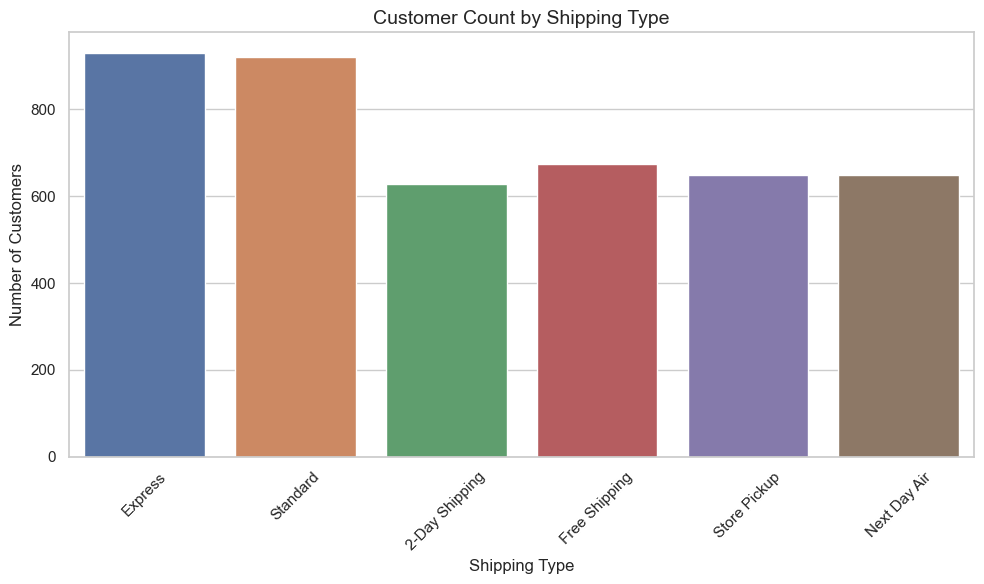

In [65]:
# Customer Count by Shipping Type

plt.figure(figsize=(10,6))

sns.barplot(
    data=shipping_summary,
    x="shipping_type",
    y="customer_count",
    hue="shipping_type",   # gives different colors
    legend=False
)

plt.title("Customer Count by Shipping Type", fontsize=14)
plt.xlabel("Shipping Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

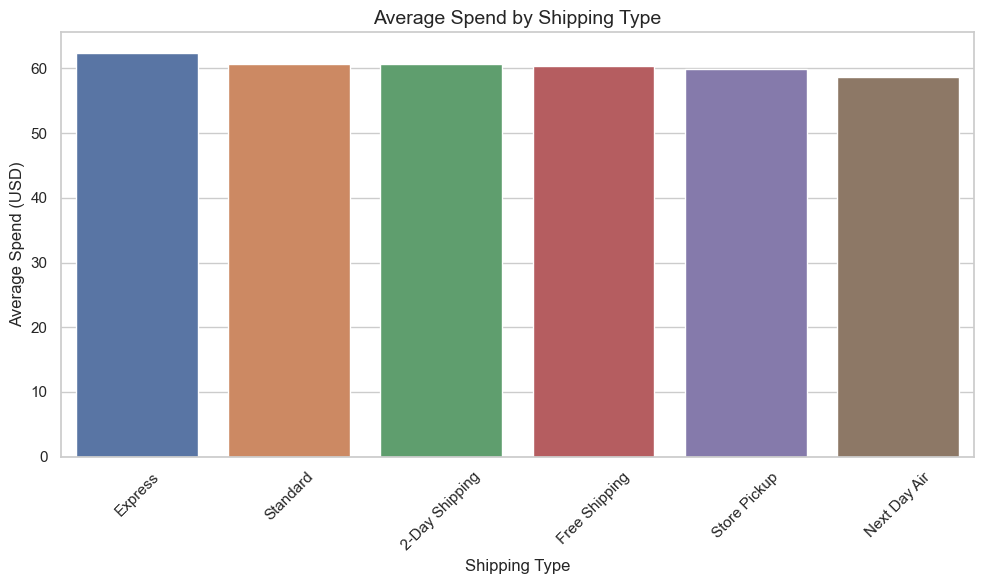

In [66]:
#Average Spend by Shipping Type

plt.figure(figsize=(10,6))

sns.barplot(
    data=shipping_summary,
    x="shipping_type",
    y="average_spend",
    hue="shipping_type",   # gives different colors
    legend=False
)

plt.title("Average Spend by Shipping Type", fontsize=14)
plt.xlabel("Shipping Type")
plt.ylabel("Average Spend (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()